In [84]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [68]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path
)

Info about columns:
    - tenure: months the employee has in the company.
    - MultipleLines: whether the customer has multiple lines or not (Yes, No, No phone service).
    - InternetService: customer’s internet service provider (DSL, Fiber optic, No).
    - OnlineSecurity: whether the customer has online security or not (Yes, No, No internet service).

In [69]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [71]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [72]:
df['Churn'].value_counts(normalize=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Data cleaning

In [73]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [74]:
# We can check every unique value in each column, to see if anything has a suspicious value.

for column in df:
    print(f"{column}: {df[column].unique()}")

"""
    Things to do:

        * Drop customer id.
        * Simplify multicategory flags to 0 and 1:
            - 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies'.
        * Convert 'Yes' = 1, 'No' = 0:
            - 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'.
        * Convert gender column to 0 and 1.
        * Cast from String to float: 
            - 'TotalCharges'.
        * Convert into binary dummy columns:
            - 'Contract', 'PaymentMethod'.
"""

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

"\n    Things to do:\n\n        * Drop customer id.\n        * Simplify multicategory flags to 0 and 1:\n            - 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',\n            'StreamingMovies'.\n        * Convert 'Yes' = 1, 'No' = 0:\n            - 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'.\n        * Convert gender column to 0 and 1.\n        * Cast from String to float: \n            - 'TotalCharges'.\n        * Convert into binary dummy columns:\n            - 'Contract', 'PaymentMethod'.\n"

In [75]:
# Drop customerID if it exists (not useful for prediction)

if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges: convert empty strings (" ") to NaN, cast to float, fill missing with 0

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True))
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

# Simplify redundant multi-category flags ('No service' -> 'No')

no_service_cols = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in no_service_cols:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

# Convert simple 'Yes'/'No' and 'Female'/'Male' binary columns to 1 and 0

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# Map gender (Female = 1, Male = 0)

if 'gender' in df.columns:
    df['gender'] = (df['gender'] == 'Female').astype(int)

# One-Hot Encode remaining multi-category features directly into df

cat_cols = ['InternetService', 'Contract', 'PaymentMethod'] + no_service_cols
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [76]:
# Verify results

print(f"Dataset shape: {df.shape}")
print("\nData types count:")
print(df.dtypes.value_counts())
df.head()
df.describe()

Dataset shape: (7043, 24)

Data types count:
int64      22
float64     2
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,0.265370,...,0.216101,0.335794,0.228880,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561,...,0.411613,0.472301,0.420141,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,...,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Model Training and Comparison (Logistic Regression, RandomForest)

In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train / Test Split (80% train, 20% test with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Scaled Logistic Regression (Pipeline prevents overwriting)
lr_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Compare Performance
print("--- Logistic Regression ---")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(classification_report(y_test, lr_preds))

print("\n--- Random Forest ---")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(classification_report(y_test, rf_preds))

#roc-auc: 0.8419, 0.8288

--- Logistic Regression ---
ROC-AUC: 0.8415
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Random Forest ---
ROC-AUC: 0.8280
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



Visualizations

C:\Users\Pablo\AppData\Local\Temp\ipykernel_19392\797425179.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


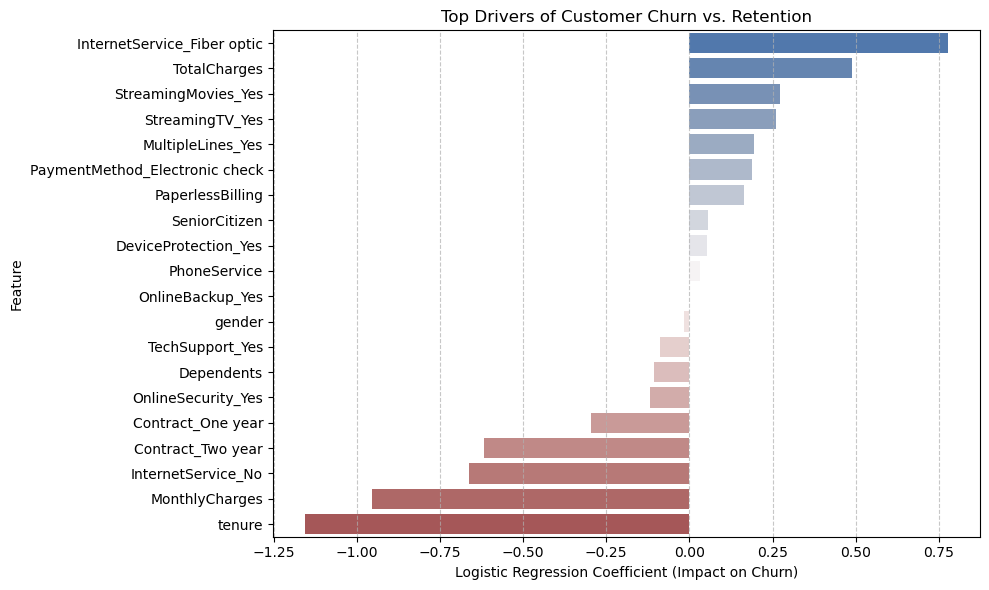

In [83]:
# Extract coefficients from the logistic regression pipeline step
model_step = scaled_lr_model.named_steps['logisticregression']
feature_names = X.columns

# Build a dataframe of feature weights
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_step.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# Plot top 10 churn drivers and top 10 retention drivers
plt.figure(figsize=(10, 6))
sns.barplot(
    data=pd.concat([coef_df.head(10), coef_df.tail(10)]), 
    x='Coefficient', 
    y='Feature', 
    palette='vlag'
)
plt.title('Top Drivers of Customer Churn vs. Retention')
plt.xlabel('Logistic Regression Coefficient (Impact on Churn)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

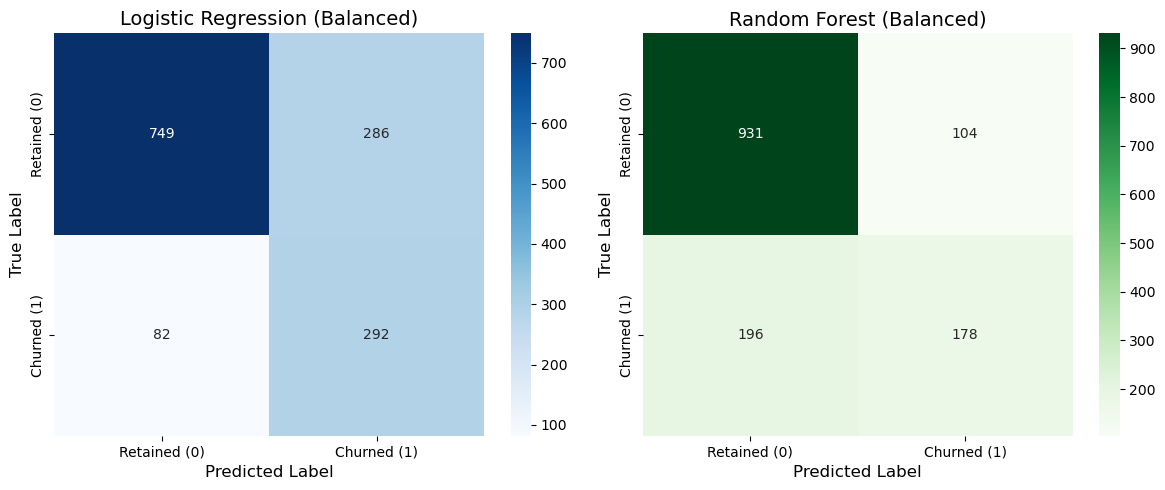

In [ ]:
# Compute confusion matrices
cm_lr = confusion_matrix(y_test, lr_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

# Set up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Logistic Regression Confusion Matrix
sns.heatmap(
    cm_lr, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0],
    xticklabels=['Retained (0)', 'Churned (1)'],
    yticklabels=['Retained (0)', 'Churned (1)']
)
axes[0].set_title('Logistic Regression (Balanced)', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot Random Forest Confusion Matrix
sns.heatmap(
    cm_rf, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    ax=axes[1],
    xticklabels=['Retained (0)', 'Churned (1)'],
    yticklabels=['Retained (0)', 'Churned (1)']
)
axes[1].set_title('Random Forest (Balanced)', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()